In [1]:
import magritte.core  as magritte             # Core functionality
import numpy as np
import os
import yt
import matplotlib.pyplot as plt
import matplotlib
import astropy.constants as constants

matplotlib.rc('font', family='serif')

from scipy.spatial import Delaunay, cKDTree   # Finding neighbors

In [2]:
#wdir = "/lhome/thomasc/Magritte-examples/Comoving/Phantom_3D_fullNLTE/"
wdir = "/STER/thomasc/Magritte_comoving/Magritte-examples/Phantom_3D_fullNLTE"
J_file_feautrier = os.path.join(wdir, 'J_feautrier.npy')
J_file_comoving = os.path.join(wdir, 'J_comoving.npy')
J_file_comapp = os.path.join(wdir, 'J_comapp.npy')
J_file_shortchar = os.path.join(wdir, 'J_shortchar.npy')
model_file_rec = os.path.join(wdir, 'wind_red_rec.hdf5')   # reduced 3D Phantom Magritte model
model_file_original = os.path.join(wdir, 'model_Phantom_3D_for_comoving.hdf5')   # reduced 3D Phantom Magritte model

J_file_original_comoving = os.path.join(wdir, 'J_original_comoving.npy')
J_file_original_feautrier = os.path.join(wdir, 'J_original_feautrier.npy')
J_file_original_comapp = os.path.join(wdir, 'J_original_comapp.npy')

NLTE_J_file_feaut = os.path.join(wdir, 'NLTE_J_rec.npy')
NLTE_J_file_comoving = os.path.join(wdir, 'NLTE_J_comoving.npy')
NLTE_J_file_comapp = os.path.join(wdir, 'NLTE_J_comoving_approx.npy')

# J_file_feautrier_2lines = os.path.join(wdir, 'J_feautrier_2lines.npy')
# J_file_comoving_2lines = os.path.join(wdir, 'J_comoving_2lines.npy')
# J_file_shortchar_2lines = os.path.join(wdir, 'J_shortchar_2lines.npy')

Loading the different saved J's for comparing them

In [3]:
J_feautrier = np.load(J_file_feautrier)[:,1]
J_comoving = np.load(J_file_comoving)[:,1]
J_comapp = np.load(J_file_comapp)[:,1]
#J_shortchar = np.load(J_file_shortchar)[:,1]

J_feautrier_original = np.load(J_file_original_feautrier)[:,1]
J_comoving_original = np.load(J_file_original_comoving)[:,1]
J_comapp_original = np.load(J_file_original_comapp)[:,1]

NLTE_J_feautrier = np.load(NLTE_J_file_feaut)[:,1]
NLTE_J_comoving = np.load(NLTE_J_file_comoving)[:,1]
NLTE_J_comapp = np.load(NLTE_J_file_comapp)[:,1]

# J_feautrier_l0 = np.load(J_file_feautrier_2lines)[:,0]
# J_comoving_l0 = np.load(J_file_comoving_2lines)[:,0]
# J_shortchar_l0 = np.load(J_file_shortchar_2lines)[:,0]

# J_feautrier_l1 = np.load(J_file_feautrier_2lines)[:,1]
# J_comoving_l1 = np.load(J_file_comoving_2lines)[:,1]
# J_shortchar_l1 = np.load(J_file_shortchar_2lines)[:,1]



In [4]:
print(J_feautrier.shape)
print(J_comoving.shape)
print(J_comapp.shape)
#print(J_shortchar.shape)

(52258,)
(52258,)
(52258,)


Load all models again in order to obtain the corresponding grids.

In [5]:
model_rec = magritte.Model(model_file_rec)
model_original = magritte.Model(model_file_original)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /STER/thomasc/Magritte_comoving/Magritte-examples/Phantom_3D_fullNLTE/wind_red_rec.hdf5
-------------------------------------------
Reading parameters...
Reading points...
Reading rays...
Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 1
read sym CO
nlev = 41
nrad = 40
Reading collisionPartner...
Reading collisionPartner...
Reading quadrature...
Reading radiation...
Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 52258
  nrays      = 48
  nboundary  = 1202


Obtain delaunay triangulations (might take a few minutes for the original grid)

In [6]:
position_rec = np.array(model_rec.geometry.points.position)
delaunay_rec = Delaunay(position_rec)
print(delaunay_rec)
position_original = np.array(model_original.geometry.points.position)
delaunay_original = Delaunay(position_original)
velocity_original = np.array(model_original.geometry.points.velocity)
#Deleting the model objects to free memory
del model_rec
del model_original

Plot the velocity field

[11852.32019114 13484.4277033  13453.64403666 ... 10238.99907763
 10976.10938908 11594.12772648] 885501 885501


yt : [INFO     ] 2024-11-08 10:27:41,896 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-11-08 10:27:41,897 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-11-08 10:27:41,898 Parameters: domain_left_edge          = [-4.10031269e+13 -4.10031269e+13 -4.09575680e+13]
yt : [INFO     ] 2024-11-08 10:27:41,899 Parameters: domain_right_edge         = [4.10031269e+13 4.10031269e+13 4.09575680e+13]
yt : [INFO     ] 2024-11-08 10:27:41,900 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-11-08 10:27:42,594 xlim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2024-11-08 10:27:42,596 ylim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2024-11-08 10:27:42,599 xlim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2024-11-08 10:27:42,600 ylim = -41003126946201.890625 41003126946201.890625
yt : [INFO     ] 2024-11-08 10:27:42,602 Making a fixed resolution buffer of (('connect1', '||v||')) 800 by 800



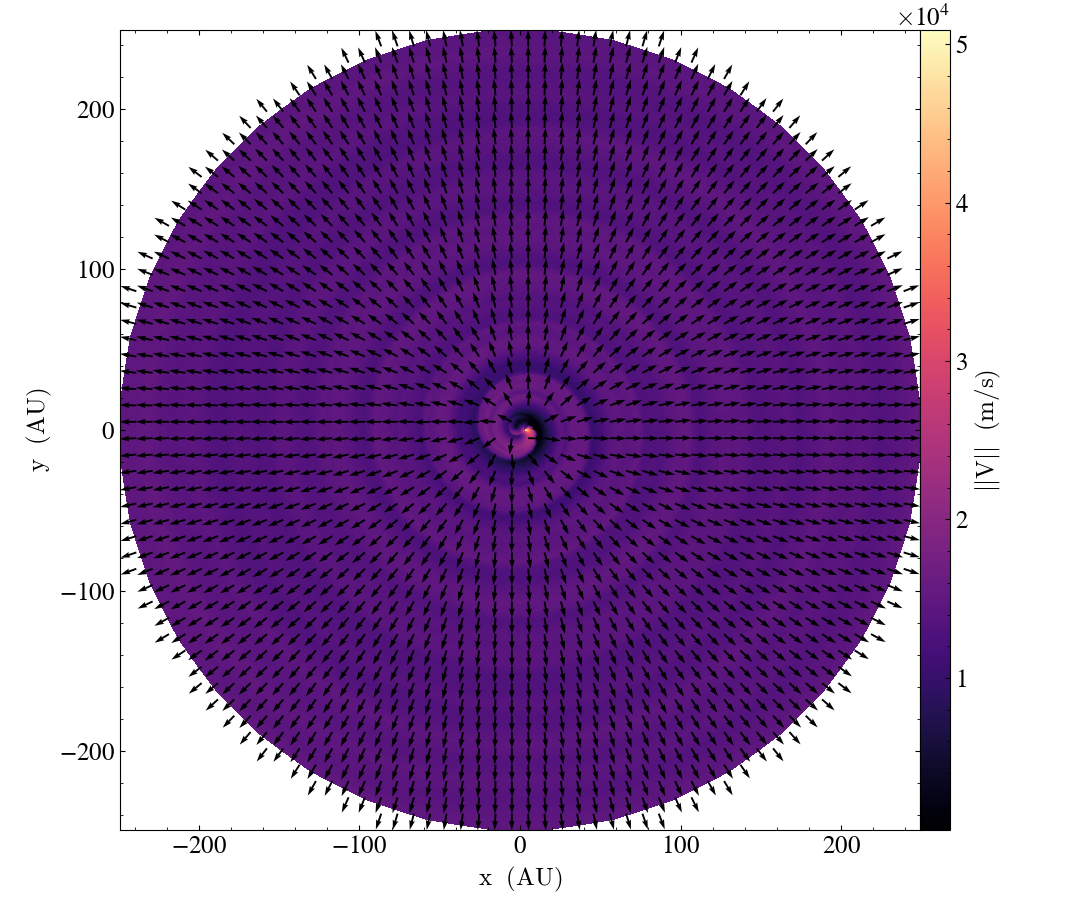

In [17]:
#computing the radial velocity
radial_velocity = np.sum(velocity_original*constants.c.si.value*position_original/np.linalg.norm(position_original, axis=1)[:, None], axis=1)#in m/s
velocity_norm = np.linalg.norm(velocity_original, axis=1)*constants.c.si.value
print(radial_velocity, len(radial_velocity), len(position_original))

ds_rv = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64), # yt expects cm not m; err we can also specify the length unit
    node_data    = {('connect1', '||v||'): velocity_norm[delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s, 
                    ('connect1', 'velocity_x'): velocity_original[:, 0][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s, 
                    ('connect1', 'velocity_y'): velocity_original[:, 1][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s,
                    ('connect1', 'velocity_z'): velocity_original[:, 2][delaunay_original.simplices].astype(np.float64)*yt.units.m/ yt.units.s},
    length_unit='m'
)

sl = yt.SlicePlot (ds_rv, 'z', [('connect1', '||v||')])
sl.set_cmap       (('connect1', '||v||'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(0, 'm/s'), zmax=(2e+4, 'm/s'))
sl.annotate_velocity(16, normalize=True, scale=48)
sl.set_log(("connect1", "||v||"), False)
sl.zoom(1.1)
#sl.save("radial_velocity.pdf")

Plot all computed J's on the reduced grids

In [8]:
ds_feautrier = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_feautrier[delaunay_rec.simplices].astype(np.float64)}
)

yt : [INFO     ] 2024-10-31 11:41:33,986 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:33,987 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:33,988 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:33,989 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:33,990 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2024-10-31 11:41:34,119 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:34,120 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:34,122 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:34,123 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:34,125 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800



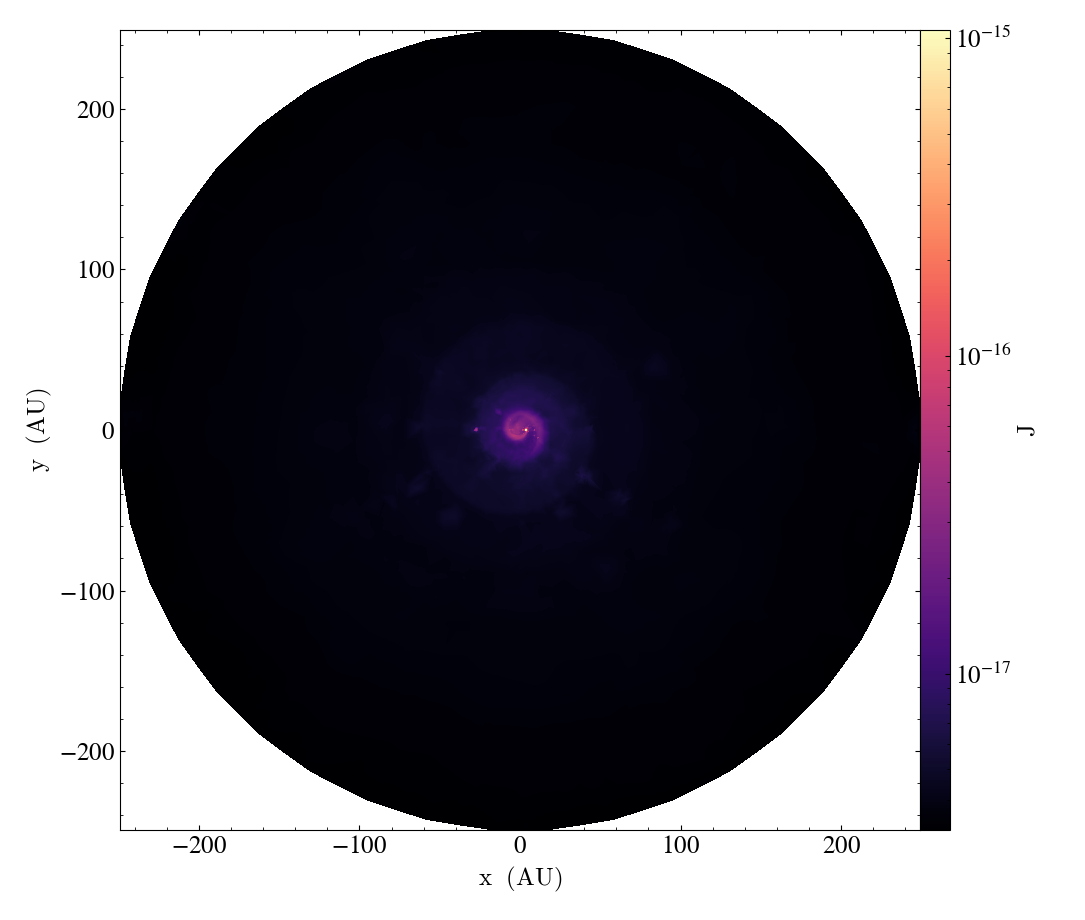

In [9]:
sl = yt.SlicePlot (ds_feautrier, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:35,481 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:35,481 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:35,482 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:35,483 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:35,484 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:35,593 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:35,594 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:35,596 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:35,597 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:35,599 Making a fixed resolution buffer of (('connect1', 'J'))


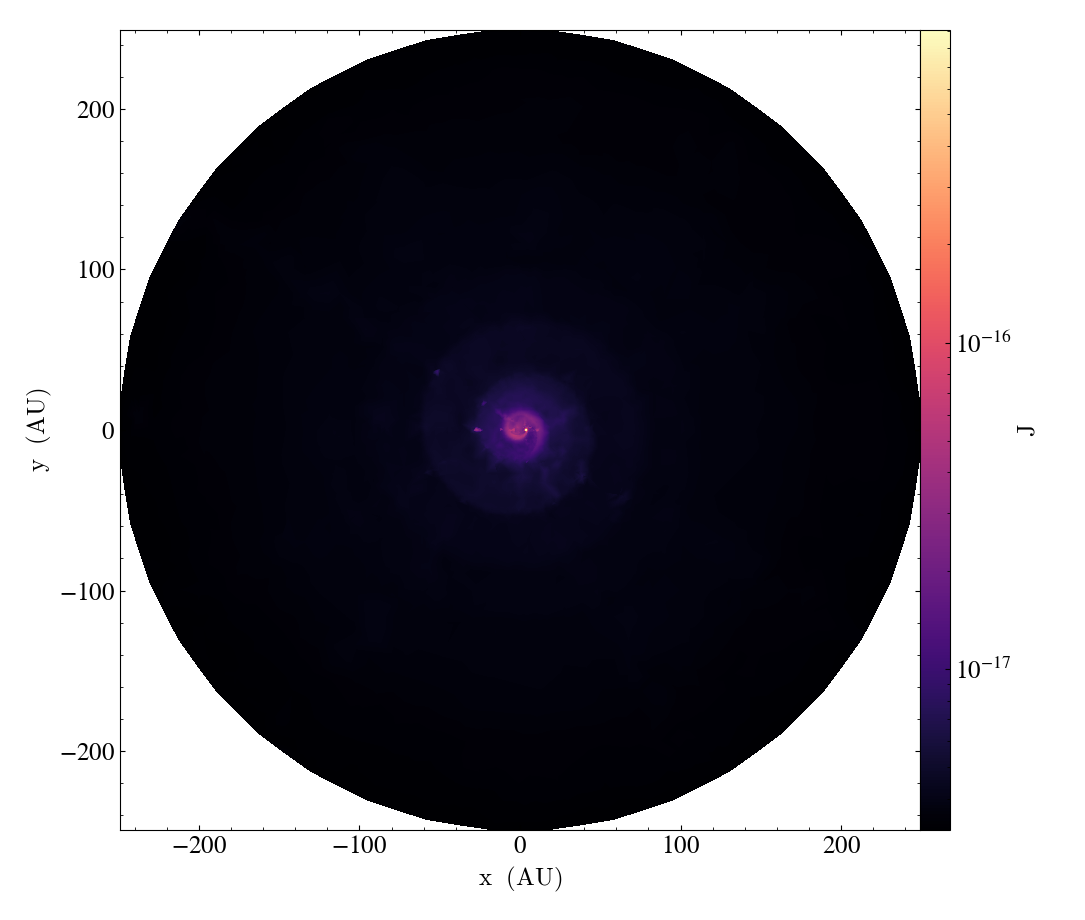

In [10]:
ds_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comoving[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comoving, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:36,885 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:36,885 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:36,886 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:36,887 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:36,888 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2024-10-31 11:41:36,999 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:37,000 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:37,002 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:37,003 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:37,005 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800



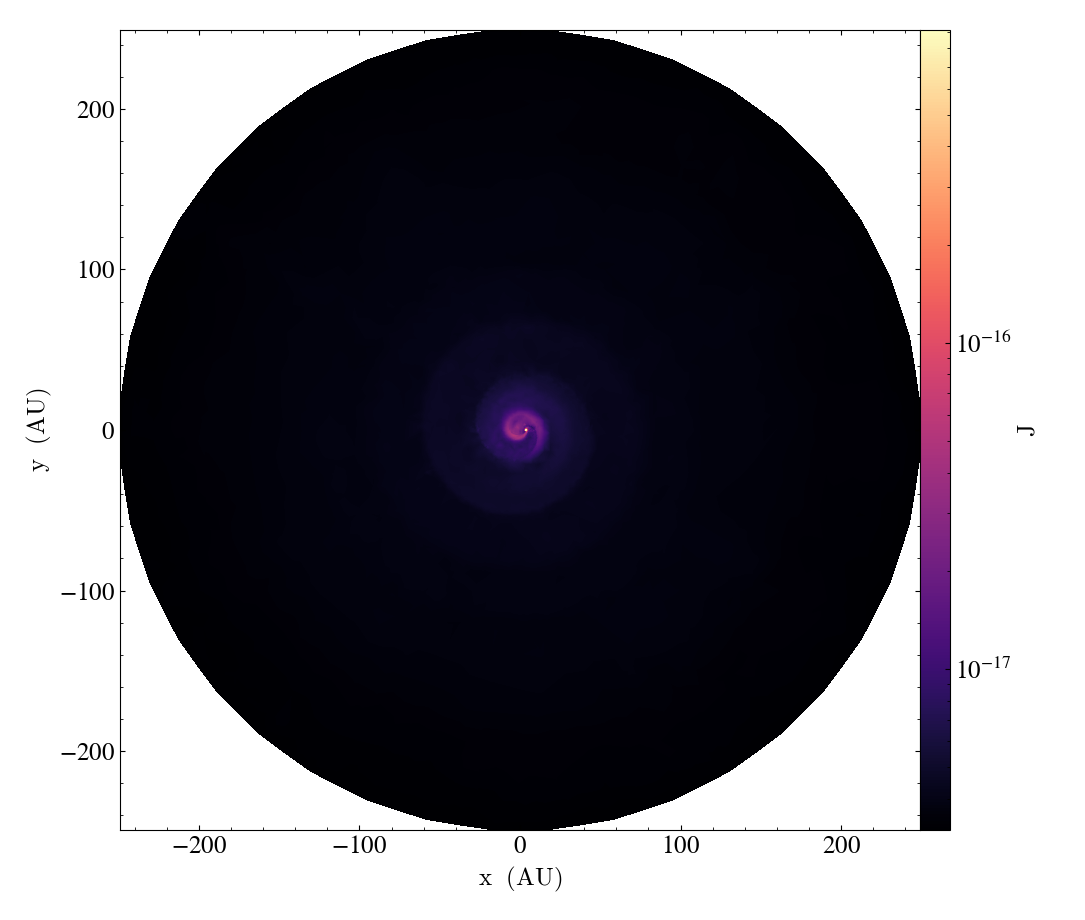

In [11]:
ds_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comapp[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comapp, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(1e-16, "1"), zmax=(2e-14, "1"))
sl.zoom           (1.1)

In [12]:
#ds_shortchar = yt.load_unstructured_mesh(
#    connectivity = delaunay_rec.simplices.astype(np.int64),
#    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#    node_data    = {('connect1', 'J'): J_shortchar[delaunay_rec.simplices].astype(np.float64)}
#)
#sl = yt.SlicePlot (ds_shortchar, 'z', ('connect1','J'))
#sl.set_cmap       (('connect1', 'J'), 'magma')
##sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
#sl.zoom           (1.1)

and now the solvers on the original grid

yt : [INFO     ] 2024-10-31 11:41:38,670 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:38,671 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:38,672 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:38,673 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:38,674 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:39,047 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:39,048 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:39,051 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:39,052 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:39,054 Making a fixed resolution buffer of (('connect1', 'J'))


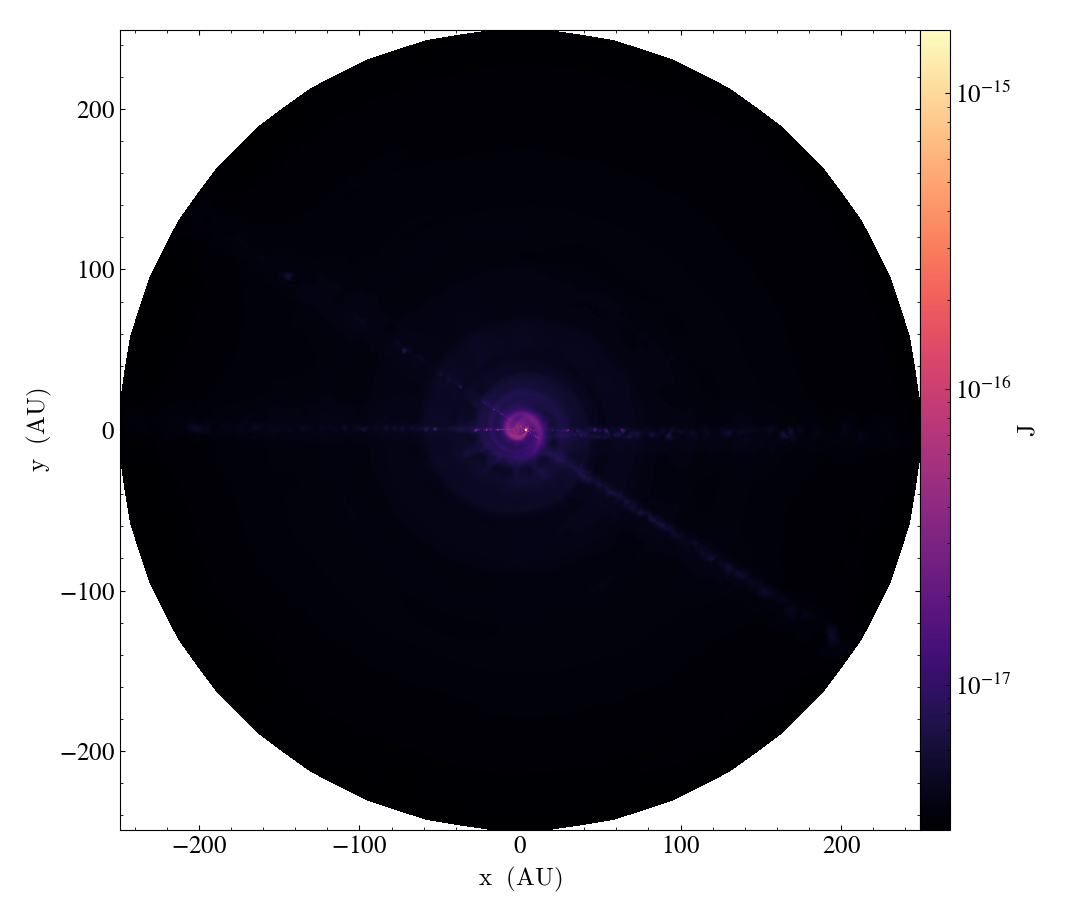

In [13]:
ds_feautrier_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_feautrier_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_feautrier_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:42,499 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:42,500 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:42,501 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:42,502 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:42,502 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:42,870 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:42,871 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:42,874 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:42,874 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:42,876 Making a fixed resolution buffer of (('connect1', 'J'))


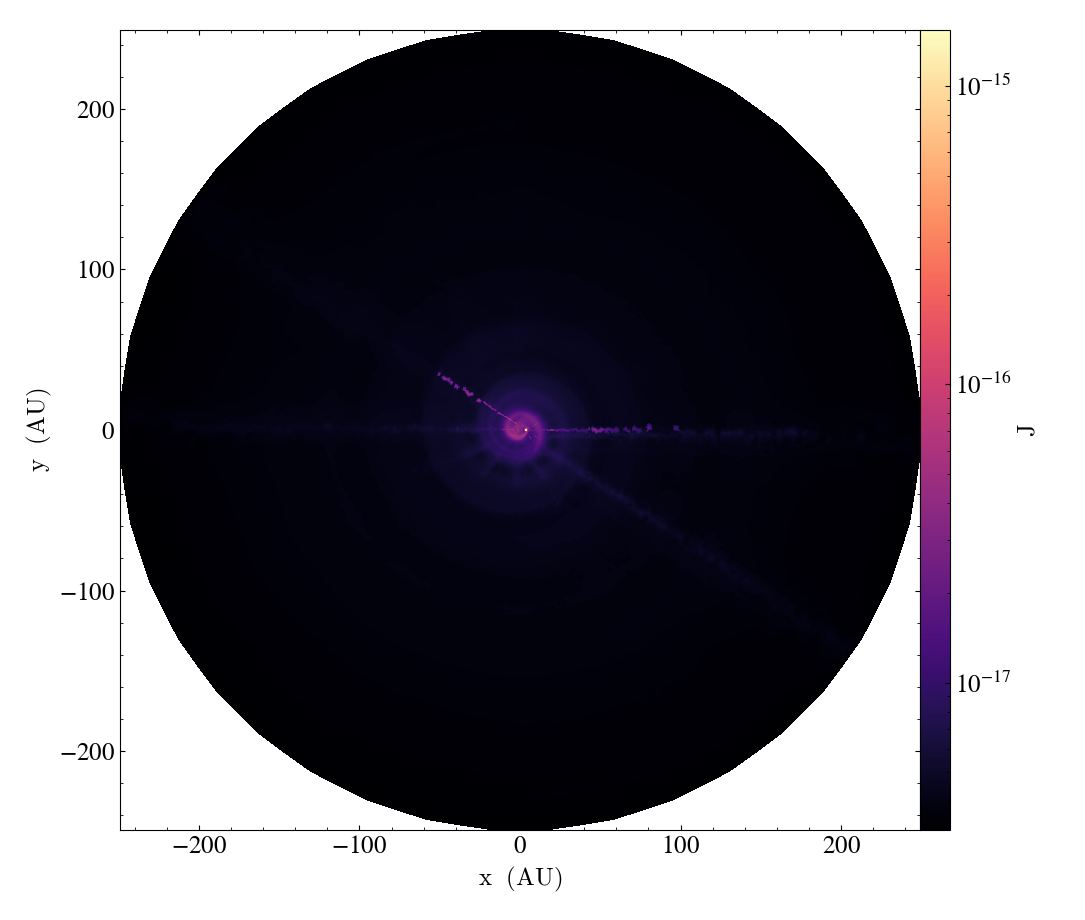

In [14]:
ds_comoving_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comoving_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comoving_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:46,305 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:46,306 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:46,307 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:46,308 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:46,309 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:46,676 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:46,677 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:46,680 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:46,680 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:46,682 Making a fixed resolution buffer of (('connect1', 'J'))


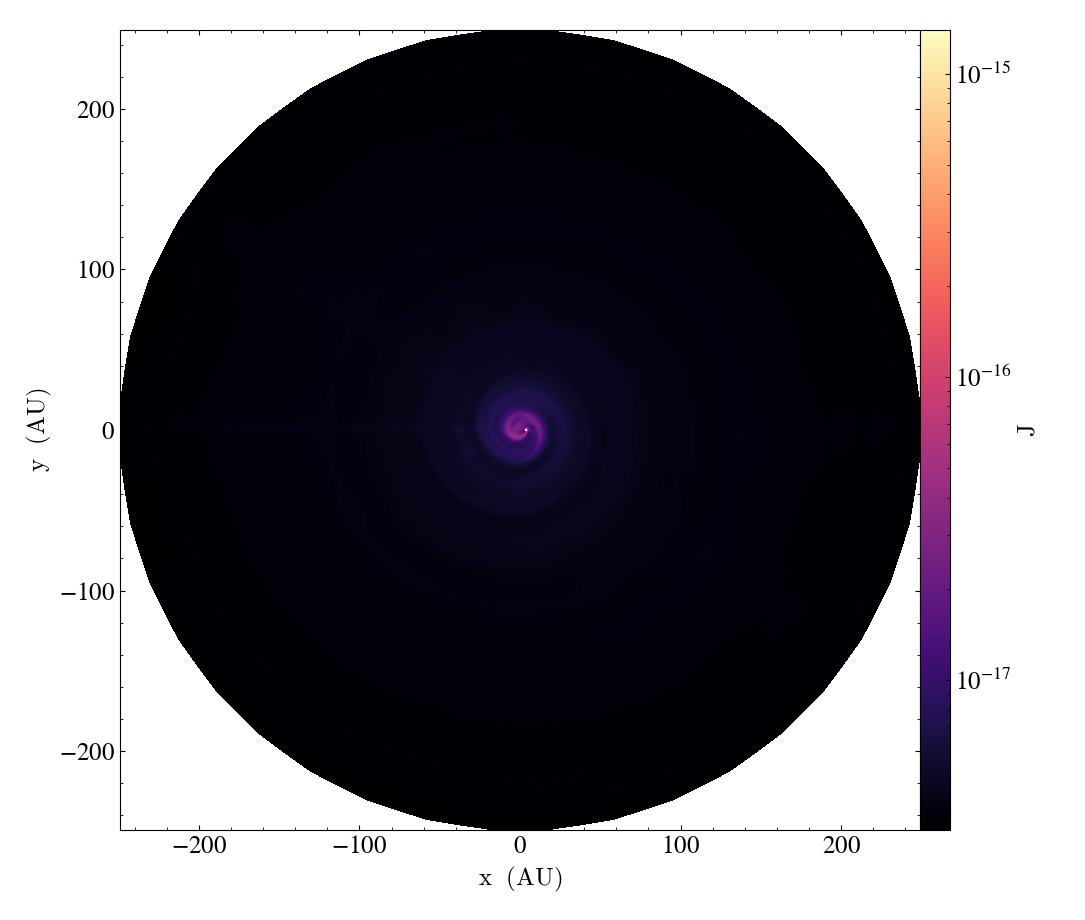

In [15]:
ds_comapp_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): J_comapp_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_comapp_original, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
#sl.set_zlim(('connect1', 'n'), zmin=(1e+6, "1"), zmax=(1e+12, "1"))
sl.zoom           (1.1)

Also plot NLTE J on original grid.

yt : [INFO     ] 2024-10-31 11:41:50,224 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:50,225 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:50,226 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:50,227 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:50,227 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:50,593 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:50,594 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:50,596 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:50,597 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:50,599 Making a fixed resolution buffer of (('connect1', 'J'))


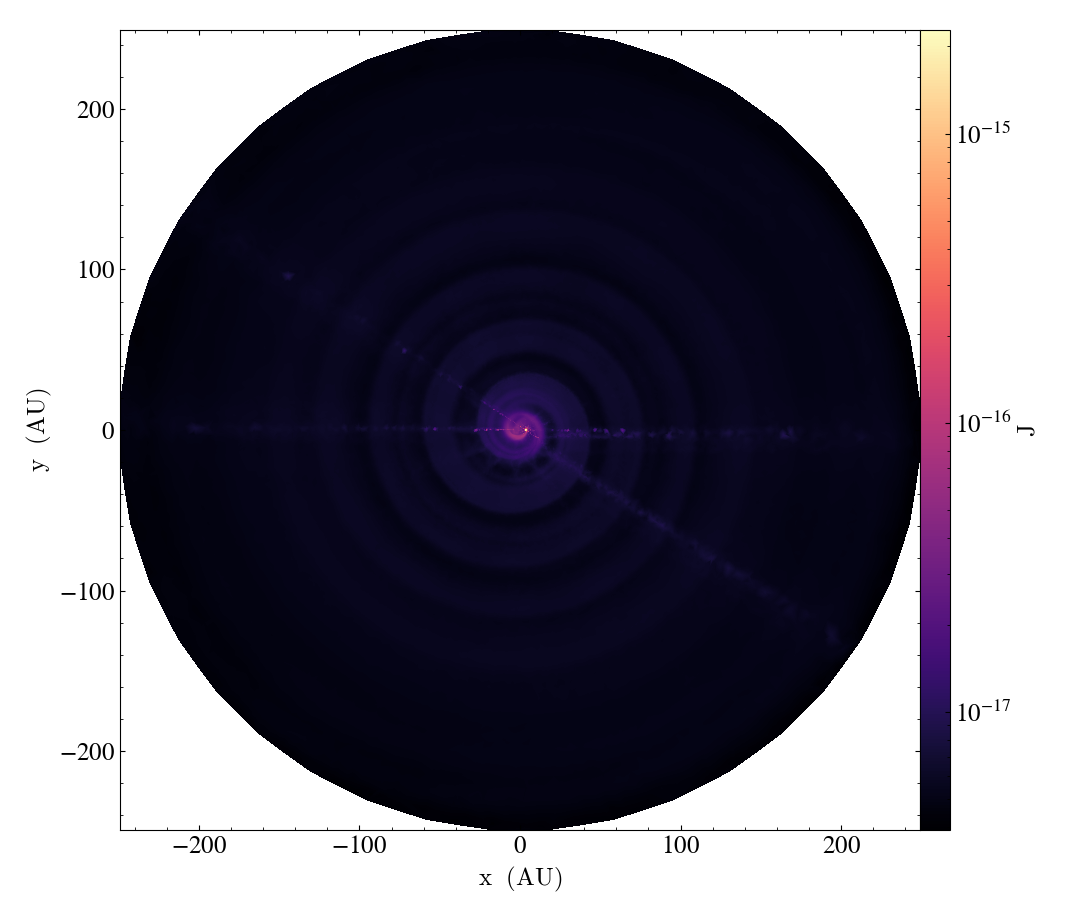

In [16]:
ds_NLTE_feautrier = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_feautrier[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_feautrier, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:54,058 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:54,059 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:54,060 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:54,061 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:54,062 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:54,427 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:54,428 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:54,431 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:54,432 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:54,434 Making a fixed resolution buffer of (('connect1', 'J'))


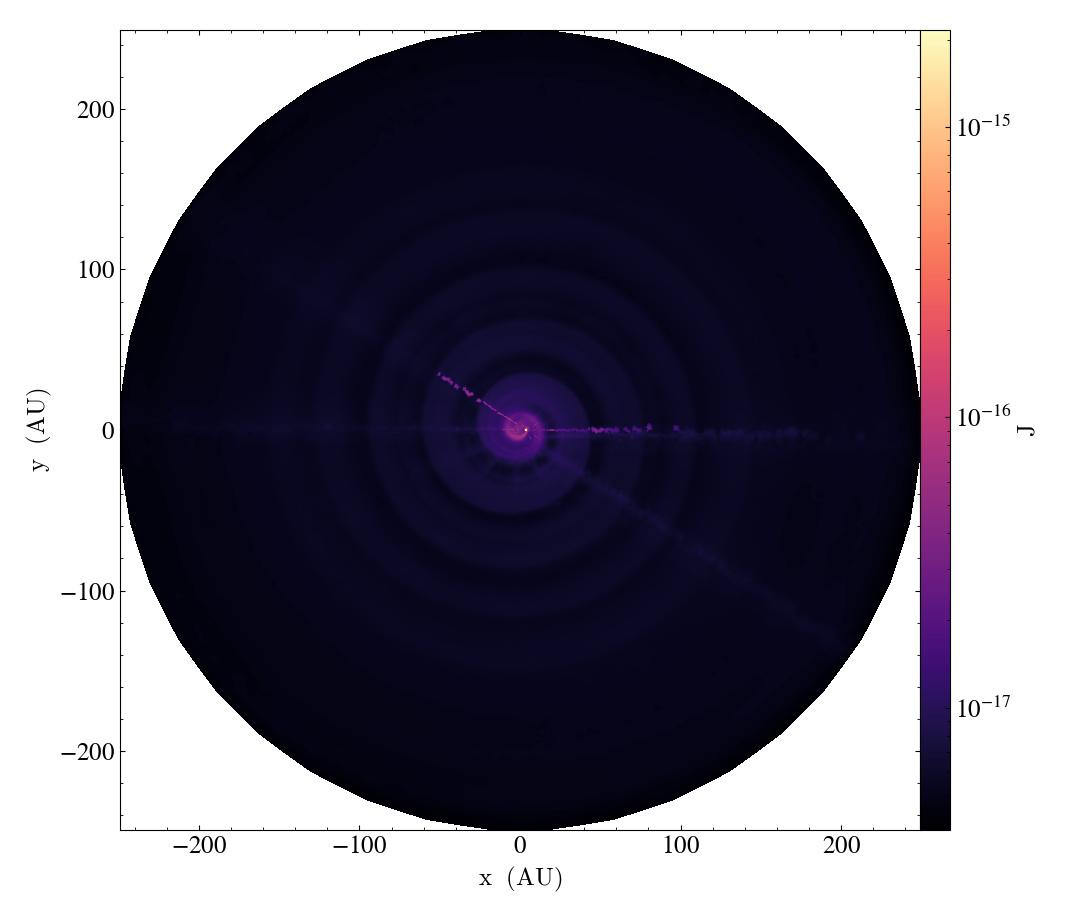

In [17]:
ds_NLTE_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_comoving[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_comoving, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:41:57,870 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:41:57,871 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:41:57,872 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:57,873 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:41:57,874 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:41:58,245 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:58,246 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:58,249 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:58,250 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:41:58,252 Making a fixed resolution buffer of (('connect1', 'J'))


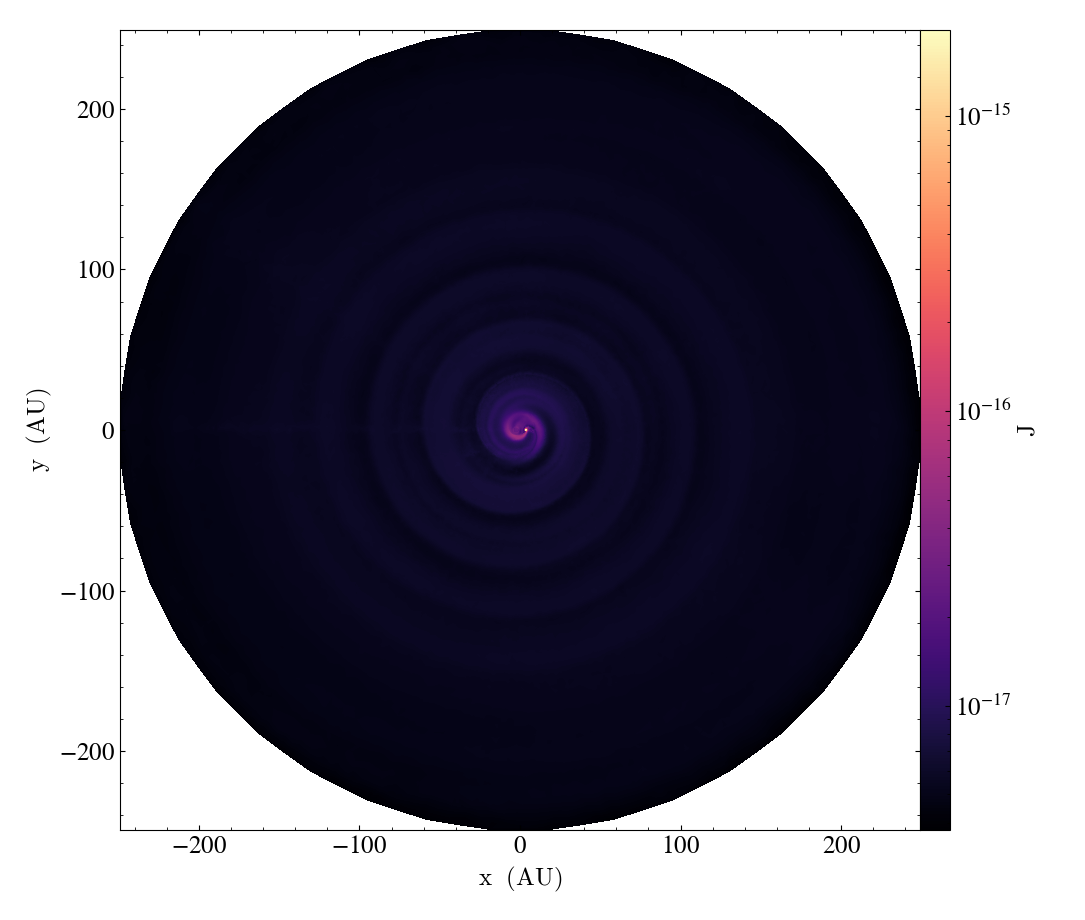

In [18]:
ds_NLTE_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J'): NLTE_J_comapp[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (ds_NLTE_comapp, 'z', ('connect1','J'))
sl.set_cmap       (('connect1', 'J'), 'magma')
# sl.set_zlim(('connect1', 'J'), zmin=(5e-16, "1"), zmax=(3e-14, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:42:01,907 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:01,908 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:01,911 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:01,911 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:01,913 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800
yt : [INFO     ] 2024-10-31 11:42:04,881 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:04,882 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:04,885 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:04,886 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:04,887 Making a fixed resolution buffer of (('connect1', 'J')) 800 by 800
yt : [IN

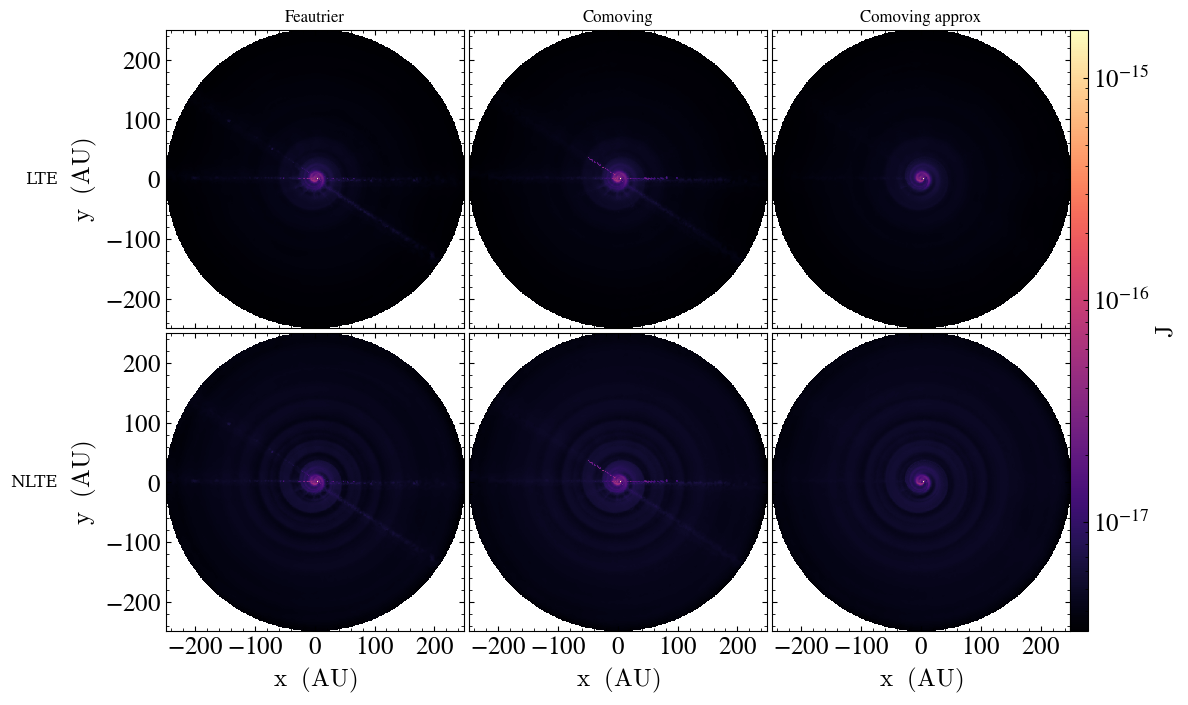

In [19]:
from mpl_toolkits.axes_grid1 import AxesGrid
fig = plt.figure()

grid = AxesGrid(fig, (0.075,0.075,0.85,0.85), nrows_ncols = (2, 3), axes_pad = 0.05, label_mode = "L", share_all = True, cbar_location="right", cbar_mode="single", cbar_size="3%", cbar_pad="0%")
data = [ds_feautrier_original, ds_comoving_original, ds_comapp_original, ds_NLTE_feautrier, ds_NLTE_comoving, ds_NLTE_comapp]
for i, dp in enumerate(data):
    sl = yt.SlicePlot (dp, 'z', ('connect1','J'))
    sl.set_cmap (('connect1', 'J'), 'magma')
    # sl.set_zlim(('connect1', 'J'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
    sl.zoom           (1.1)
    plot = sl.plots[('connect1','J')]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]
    #forced redraw
    sl._setup_plots()

#now add the column titles
grid[0].set_title("Feautrier", size='large')
grid[1].set_title("Comoving", size='large')
grid[2].set_title("Comoving approx", size='large')
#padding
pad = 5#in points
#and set the row titles, keeping the y axis label
ax = grid[0].axes
ax.annotate('LTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
ax = grid[3].axes
ax.annotate('NLTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

# plt.tight_layout()
plt.savefig('all_intensities_combined.png', dpi=300, bbox_inches='tight')
plt.show()

Project reduced computed data onto original data

In [20]:
# # Find closest points
# corresp_points_gmsh = cKDTree(position_original).query(position_gmsh)[1]
# corresp_points_haar = cKDTree(position_original).query(position_haar)[1]
corresp_points_rec = np.array(cKDTree(position_original).query(position_rec)[1])
print(corresp_points_rec)

J_original = J_feautrier_original#1 it J on original grid
J_rec = J_feautrier#1 it J on reduced grid
print(J_original)
# #and do lazy projection onto reduced grids
prj_J_original_rec = J_original[corresp_points_rec]

#err, minor negative values may occur due to numerical issues, do check whether this is still the case


rel_diff_comoving = 1.0/2.0*np.abs(J_feautrier-J_comoving)/(J_feautrier+J_comoving)
rel_diff_comapp = 1.0/2.0*np.abs(J_feautrier-J_comapp)/(J_feautrier+J_comapp)
#rel_diff_shortchar = 1.0/2.0*np.abs(J_feautrier-J_shortchar)/(J_feautrier+J_shortchar)
rel_diff_rec = 1.0/2.0*np.abs(prj_J_original_rec-J_rec)/(prj_J_original_rec+J_rec)#diff versus projection? why did I even compute this?

#also for original grid
rel_diff_comoving_original = 1.0/2.0*np.abs(J_feautrier_original-J_comoving_original)/(J_feautrier_original+J_comoving_original)
rel_diff_comapp_original = 1.0/2.0*np.abs(J_feautrier_original-J_comapp_original)/(J_feautrier_original+J_comapp_original)

#and for NLTE
rel_diff_NLTE_comoving = 1.0/2.0*np.abs(NLTE_J_feautrier-NLTE_J_comoving)/(NLTE_J_feautrier+NLTE_J_comoving)
rel_diff_NLTE_comapp = 1.0/2.0*np.abs(NLTE_J_feautrier-NLTE_J_comapp)/(NLTE_J_feautrier+NLTE_J_comapp)

[    0     1     2 ... 75381 46895 67743]
[3.17717180e-18 3.17425184e-18 3.17418238e-18 ... 3.86078115e-17
 3.95602695e-17 3.99747785e-17]


In [21]:
# print(prj_J_original_gmsh.shape)
# print(prj_J_original_haar.shape)
# print(prj_J_original_rec.shape)
print(J_original.shape)
print(NLTE_J_comapp.shape)
print(np.min(rel_diff_NLTE_comoving))
print(np.min(NLTE_J_comoving))
print(np.min(J_comoving_original))
print(np.min(J_comapp_original))

(885501,)
(885501,)
1.0371873397056007e-08
3.1591168606043586e-18
3.155824180711278e-18
3.1738119766097857e-18


Plot the relative differences (I expect the largest differences to reside in the middle)

yt : [INFO     ] 2024-10-31 11:42:25,888 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:25,889 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:25,890 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:25,891 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:25,892 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:26,015 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:26,016 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:26,018 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:26,019 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:26,021 Making a fixed resolution buffer of (('connect1', 'J_re


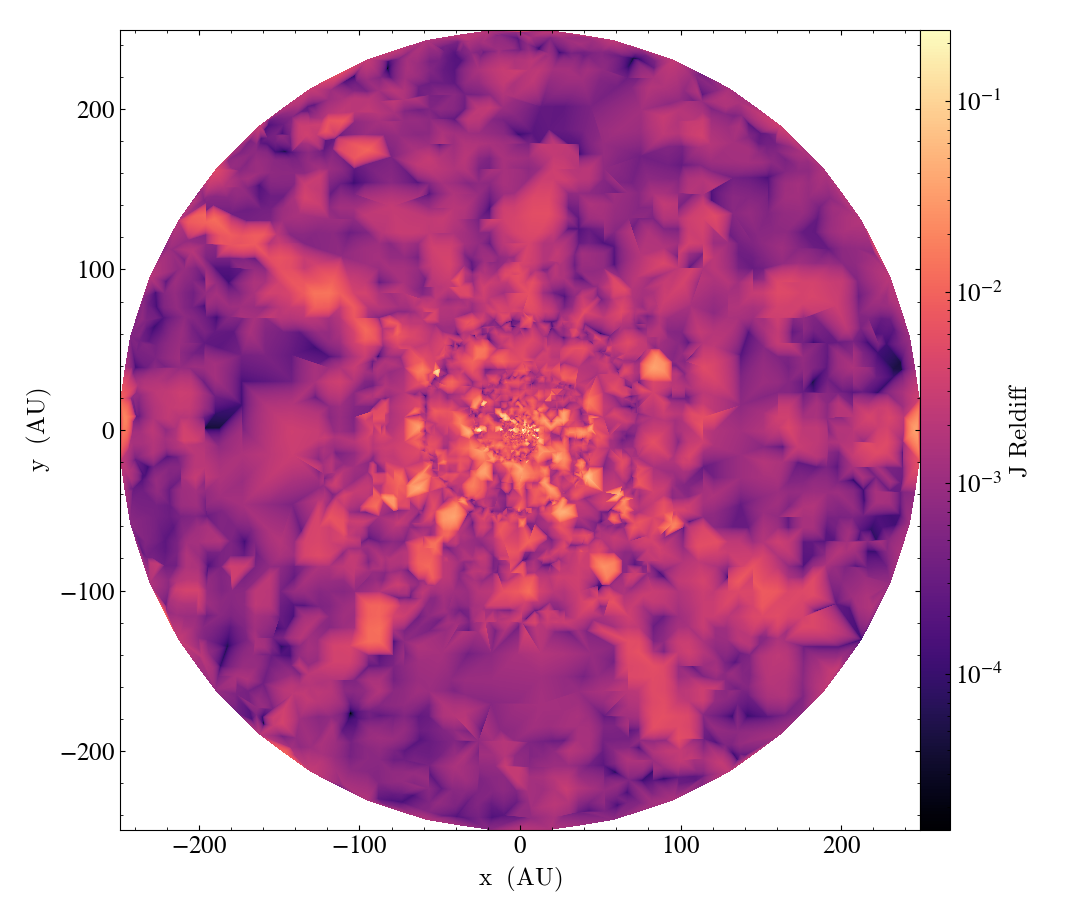

In [22]:
#comoving
diff_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comoving, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-0, "1"))
sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:42:27,500 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:27,500 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:27,501 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:27,502 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:27,503 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:27,613 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:27,614 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:27,617 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:27,617 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:27,619 Making a fixed resolution buffer of (('connect1', 'J_re


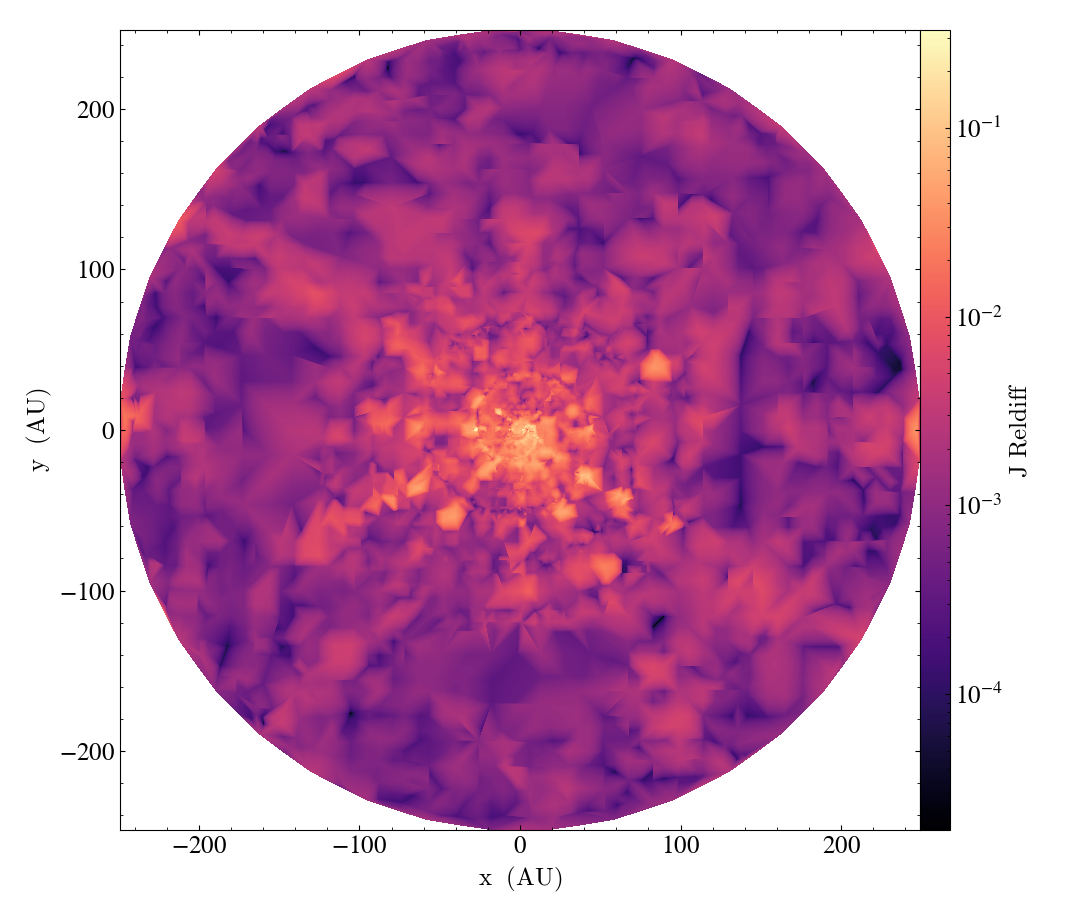

In [23]:
#comoving approx
diff_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_rec.simplices.astype(np.int64),
    coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comapp[delaunay_rec.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comapp, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)

In [24]:
# #shortchar
# diff_shortchar = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_shortchar[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_shortchar, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:42:29,385 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:29,386 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:29,387 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:29,388 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:29,389 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:29,757 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:29,758 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:29,761 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:29,762 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:29,764 Making a fixed resolution buffer of (('connect1', 'J_re


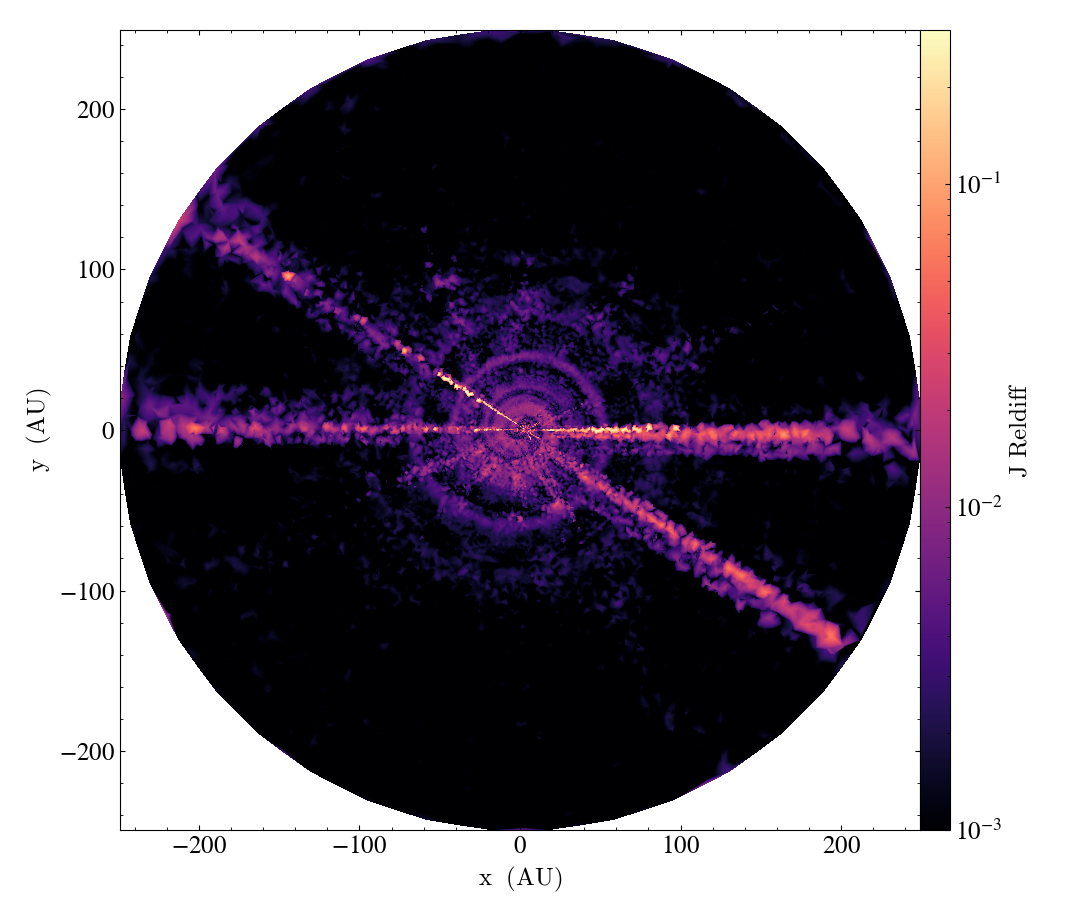

In [25]:
#comoving on original grid
diff_comoving_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comoving_original, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_comoving_original.png')

yt : [INFO     ] 2024-10-31 11:42:33,140 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:33,141 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:33,142 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:33,143 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:33,144 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:33,515 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:33,516 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:33,519 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:33,519 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:33,522 Making a fixed resolution buffer of (('connect1', 'J_re


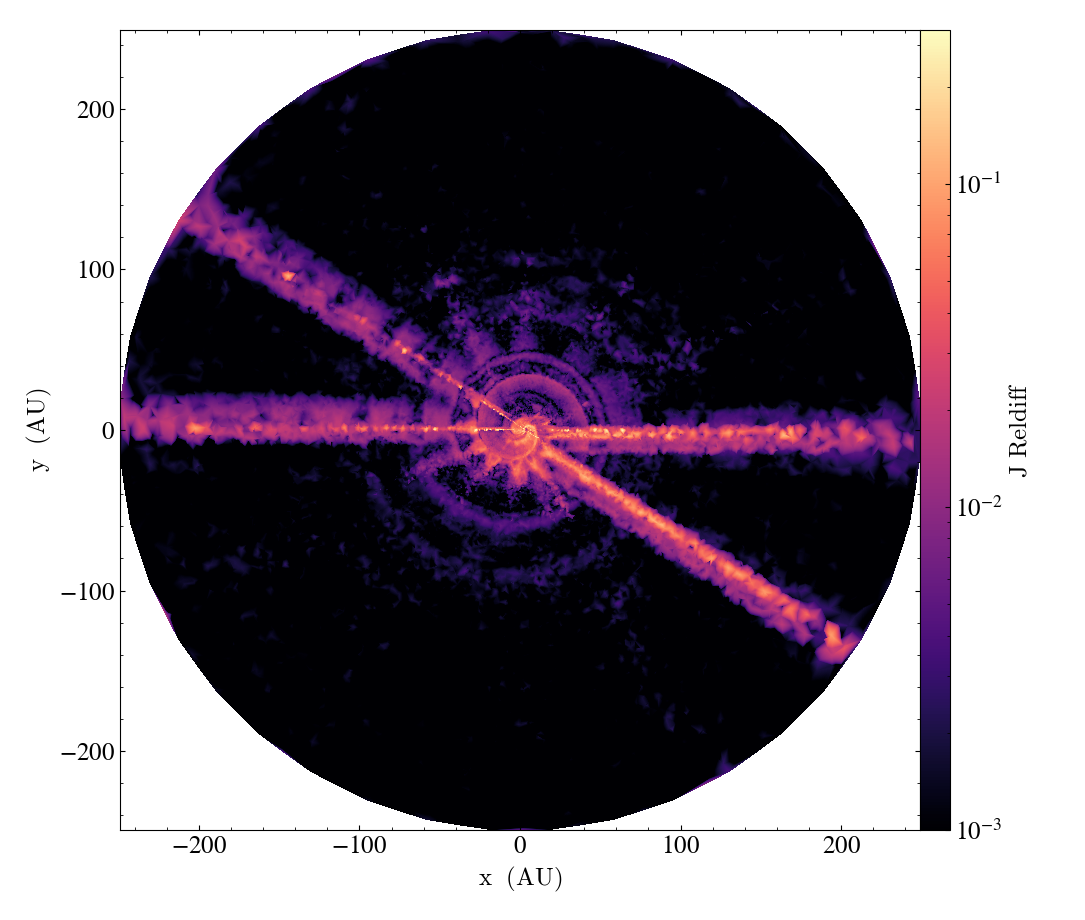

In [26]:
#comoving approx on original grid
diff_comapp_original = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_comapp_original[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_comapp_original, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_comapp_original.png')

yt : [INFO     ] 2024-10-31 11:42:37,186 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:37,187 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:37,188 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:37,189 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:37,190 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:37,572 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:37,574 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:37,576 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:37,577 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:37,579 Making a fixed resolution buffer of (('connect1', 'J_re


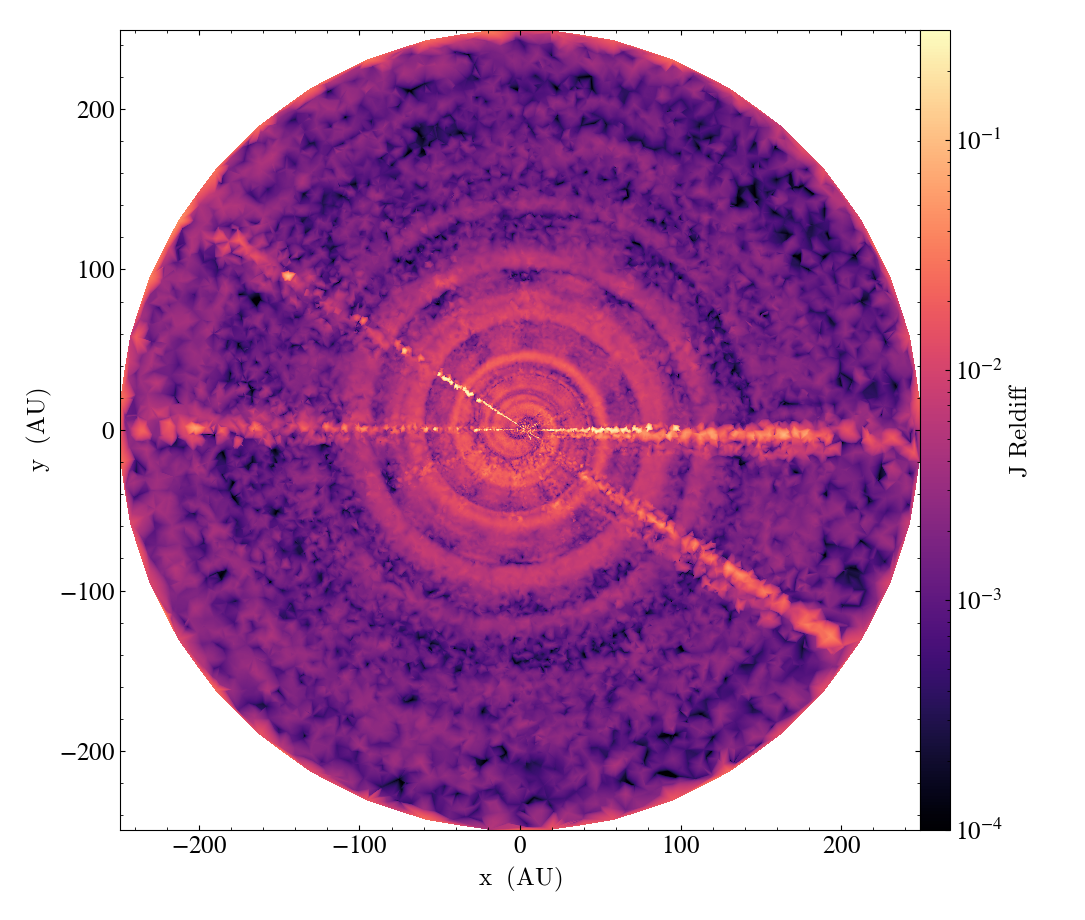

In [27]:
#NLTE diffs comoving vs feautrier
diff_NLTE_comoving = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_NLTE_comoving[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_NLTE_comoving, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-4, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_NLTE_comoving.png')

yt : [INFO     ] 2024-10-31 11:42:41,317 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:42:41,318 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:42:41,319 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:41,320 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:42:41,321 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:42:41,693 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:41,694 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:41,697 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:41,697 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:41,699 Making a fixed resolution buffer of (('connect1', 'J_re


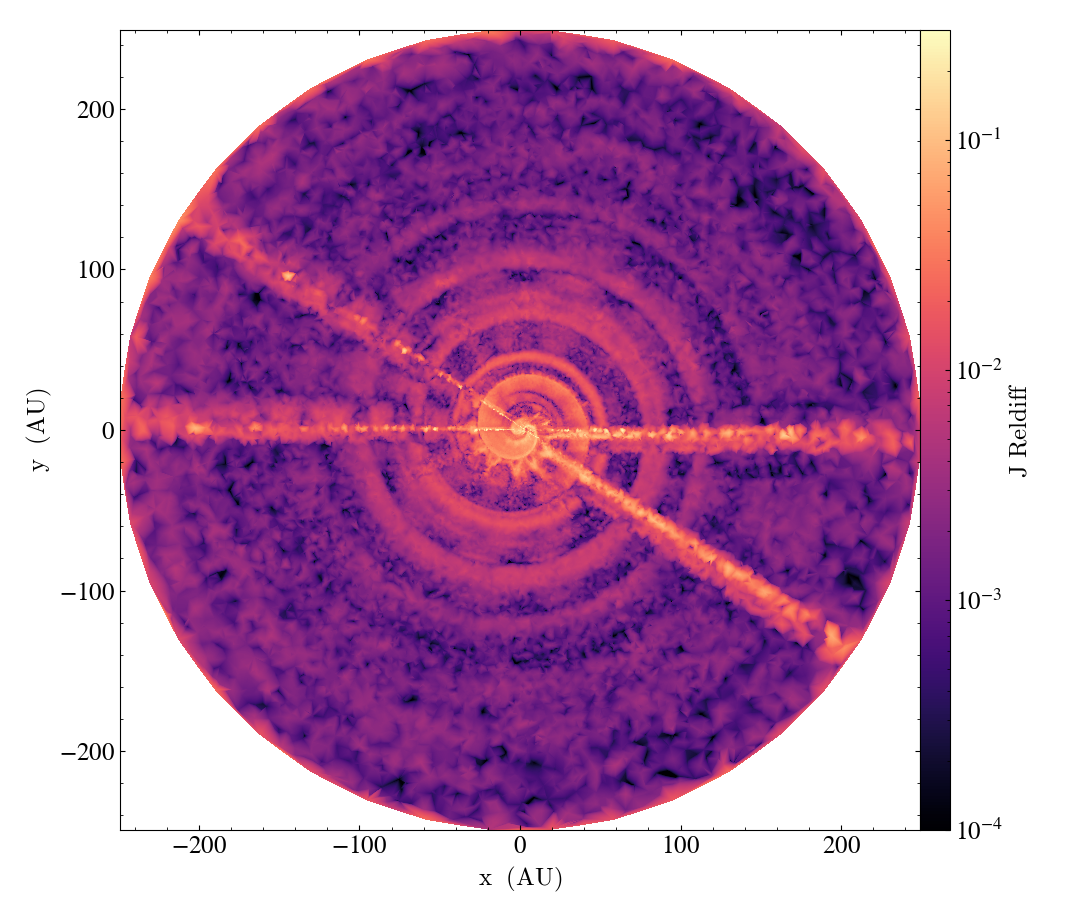

In [28]:
#NLTE diffs comoving approx vs feautrier
diff_NLTE_comapp = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): rel_diff_NLTE_comapp[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (diff_NLTE_comapp, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-4, "1"), zmax=(3e-1, "1"))
sl.zoom           (1.1)
# sl.save('diff_NLTE_comapp.png')

Now plotting all these results together in a single plot

yt : [INFO     ] 2024-10-31 11:42:45,548 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:45,549 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:45,552 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:45,552 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:45,554 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800 by 800
yt : [INFO     ] 2024-10-31 11:42:48,675 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:48,677 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:48,679 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:48,680 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:42:48,681 Making a fixed resolution buffer of (('connect1', 'J_reldiff')) 800

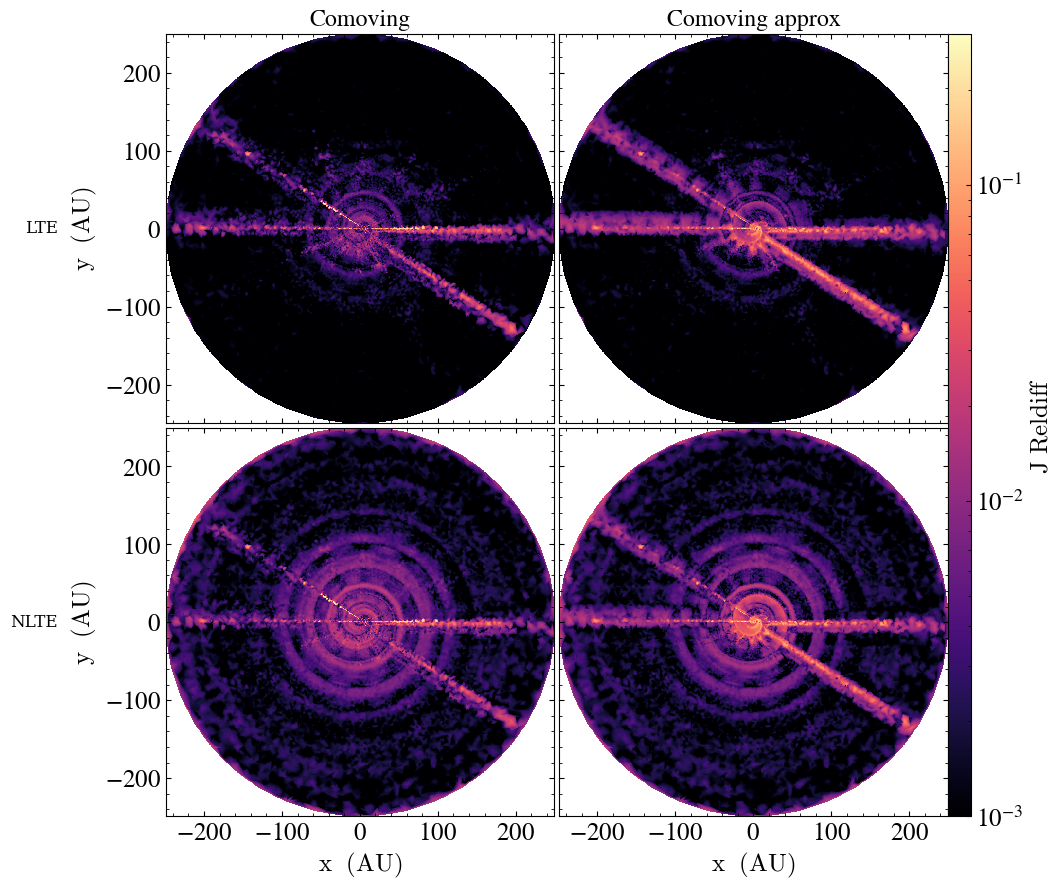

In [29]:
from mpl_toolkits.axes_grid1 import AxesGrid
fig = plt.figure()

grid = AxesGrid(fig, (0.075,0.075,0.85,0.85), nrows_ncols = (2, 2), axes_pad = 0.05, label_mode = "L", share_all = True, cbar_location="right", cbar_mode="single", cbar_size="3%", cbar_pad="0%")
data = [diff_comoving_original, diff_comapp_original, diff_NLTE_comoving, diff_NLTE_comapp]
for i, dp in enumerate(data):
    sl = yt.SlicePlot (dp, 'z', ('connect1','J_reldiff'))
    sl.set_cmap (('connect1', 'J_reldiff'), 'magma')
    sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-3, "1"), zmax=(3e-1, "1"))
    sl.zoom           (1.1)
    plot = sl.plots[('connect1','J_reldiff')]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]
    #forced redraw
    sl._setup_plots()

#now add the column titles
grid[0].set_title("Comoving", size='xx-large')
grid[1].set_title("Comoving approx", size='xx-large')
#padding
pad = 5#in points
#and set the row titles, keeping the y axis label
ax = grid[0].axes
ax.annotate('LTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
ax = grid[2].axes
ax.annotate('NLTE', xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')

# plt.tight_layout()
plt.savefig('reldiff_comoving_combined.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
# #bugged multiline diffs comoving vs feautrier
# diff_l0_comoving = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_l0[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_l0_comoving, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

In [31]:
# #multiline diffs comoving vs feautrier
# #the relative diffs sem larger, as the line is quite a bit weaker
# diff_l1_comoving = yt.load_unstructured_mesh(
#     connectivity = delaunay_rec.simplices.astype(np.int64),
#     coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): rel_diff_comoving_l1[delaunay_rec.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (diff_l1_comoving, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(3e-1, "1"))
# sl.zoom           (1.1)

Because a figure might not tell us everything, we also plot a CDF of the relative errors.
In this, we notice that some differences exist in the slopes; gmsh might do better for the smaller scale structures, while ... err, this might be incorrect; we might just need to compare on the correct grid (original grid).

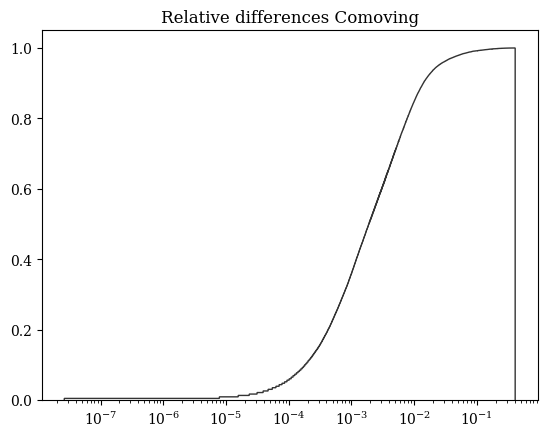

In [32]:
plt.figure()
plt.hist(rel_diff_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8, color='k')
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.title("Relative differences Comoving")
plt.show()

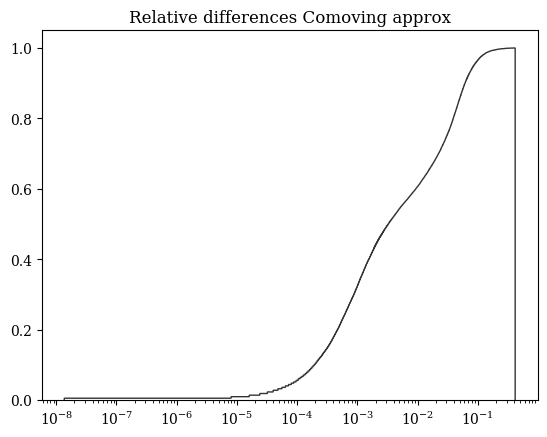

In [33]:
plt.figure()
plt.hist(rel_diff_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8, color='k')
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.title("Relative differences Comoving approx")
plt.show()

In [34]:
#plt.figure()
#plt.hist(rel_diff_shortchar, cumulative=True, label='Shortchar', density=True,
#         bins = len(rel_diff_shortchar), histtype='step', alpha=0.8, color='k')
#plt.xscale('log')
#plt.xlim(1e-6,3e-1)
#plt.title("Relative differences Shortchar")
#plt.show()

Err, we might just plot them together

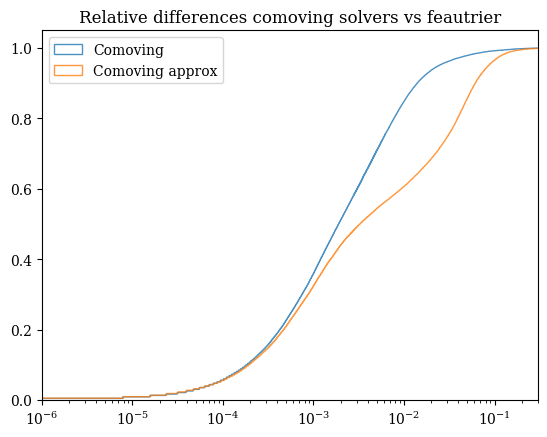

In [35]:
plt.figure()
plt.hist(rel_diff_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
#plt.hist(rel_diff_shortchar, cumulative=True, label='Shortchar', density=True,
#         bins = len(rel_diff_shortchar), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("Relative differences comoving solvers vs feautrier")
plt.show()

Also create the same plot for the original grid. (I do not see major differences, just more points at irrelevant locations being computed accurately)

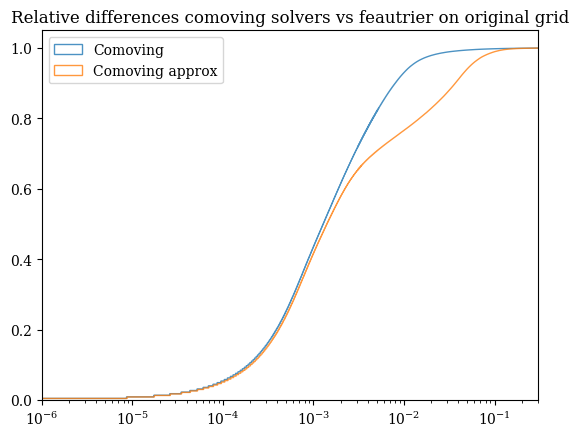

In [36]:
plt.figure()
plt.hist(rel_diff_comoving_original, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp_original, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("Relative differences comoving solvers vs feautrier on original grid")
plt.savefig("wind_model_original_reldiffs_comoving.jpg")
plt.show()

And for the NLTE J on the reduced mesh.

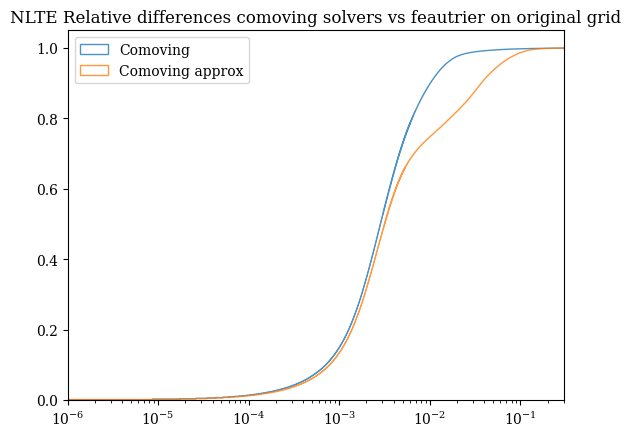

In [37]:
plt.figure()
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
plt.title("NLTE Relative differences comoving solvers vs feautrier on original grid")
plt.show()

The most useful figure will probably be all plotted together, with different line styles denoting different boundary implementations and different colors denoting LTE/NLTE results

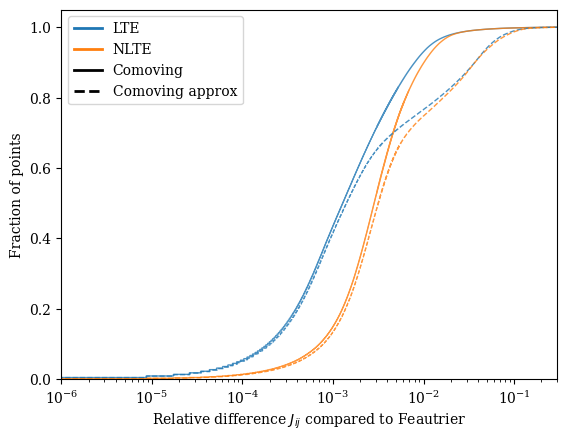

In [38]:
plt.figure()
plt.hist(rel_diff_comoving_original, cumulative=True, label='Comoving', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='Comoving NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.gca().set_prop_cycle(None)
plt.hist(rel_diff_comapp_original, cumulative=True, label='Comoving approx', density=True,
         bins = len(rel_diff_comapp), histtype='step', ls = "--", alpha=0.8)
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='Comoving approx NLTE', density=True,
         bins = len(rel_diff_comapp), histtype='step', ls = "--", alpha=0.8)
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
# plt.legend(loc = "upper left")
plt.xlim(1e-6,3e-1)
colors = ['tab:blue', 'tab:orange', 'black', 'black']
lines = [matplotlib.lines.Line2D([0], [0], color=c, linewidth=2, linestyle=ls) for c, ls in zip(colors, ['-', '-', '-', '--'])]
labels = ['LTE', 'NLTE', 'Comoving', 'Comoving approx']
plt.legend(lines, labels, loc = "upper left")
plt.xlabel(r"Relative difference $J_{ij}$ compared to Feautrier")
plt.ylabel("Fraction of points")
# plt.legend(lines, labels, loc = "upper right")
# plt.title("Relative differences comoving solvers vs feautrier on original grid")
plt.savefig("Comparison_differences_comoving_implementations_LTE_NLTE.png")
plt.show()


In [39]:
#Also get some values for fraction of values below a certain accuracy threshold
threshold = 1e-2
print("Comoving: ", np.sum(rel_diff_comoving_original < threshold)/len(rel_diff_comoving_original))
print("Comoving approx: ", np.sum(rel_diff_comapp_original < threshold)/len(rel_diff_comapp_original))
print("Comoving NLTE: ", np.sum(rel_diff_NLTE_comoving < threshold)/len(rel_diff_NLTE_comoving))
print("Comoving approx NLTE: ", np.sum(rel_diff_NLTE_comapp < threshold)/len(rel_diff_NLTE_comapp))

Comoving:  0.9300667079992004
Comoving approx:  0.7658670063613706
Comoving NLTE:  0.8976229275856267
Comoving approx NLTE:  0.7474503134383812


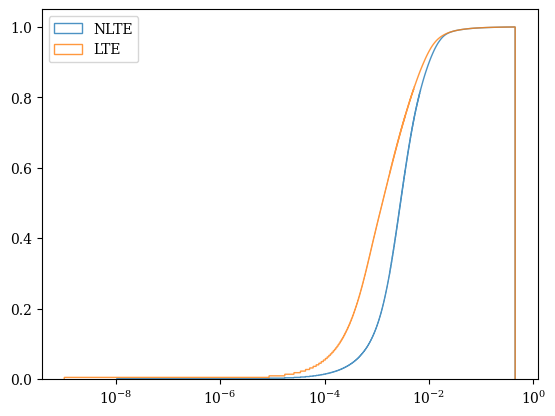

In [40]:
#err compare vs rel diffs in single iteration
plt.figure()
plt.hist(rel_diff_NLTE_comoving, cumulative=True, label='NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comoving_original, cumulative=True, label='LTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.xscale('log')
# plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
# plt.title("NLTE vs LTE relative differences comoving solver on original grid")
plt.show()

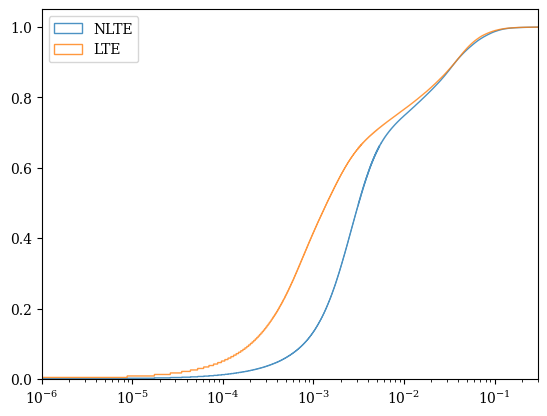

In [41]:
#compare comoving approx NLTE vs rel diffs in single iteration
plt.figure()
plt.hist(rel_diff_NLTE_comapp, cumulative=True, label='NLTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.hist(rel_diff_comapp_original, cumulative=True, label='LTE', density=True,
         bins=len(rel_diff_comoving), histtype='step', alpha=0.8)
plt.xscale('log')
plt.xlim(1e-6,3e-1)
plt.legend(loc = "upper left")
# plt.title("NLTE vs LTE relative differences comoving approx solver on original grid")
plt.show()

Instead of the above, we might just need to interpolate the results instead onto the original grid.

In [42]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
# interp_func_J_gmsh = LinearNDInterpolator (position_gmsh, J_gmsh)
# interp_func_J_haar = LinearNDInterpolator (position_haar, J_haar)

#nearest neighbor interpolation, as the linear does not seem to work for the haar mesh...
# interp_func_J_gmsh = NearestNDInterpolator (position_gmsh, J_gmsh)
# interp_func_J_haar = NearestNDInterpolator (position_haar, J_haar)
interp_func_J_rec = NearestNDInterpolator (position_rec, J_rec)

# prj_J_gmsh_original = interp_func_J_gmsh(position_original)
# prj_J_haar_original = interp_func_J_haar(position_original)

In [43]:
# prj_J_haar_original = interp_func_J_haar(position_original)

In [44]:
# prj_J_gmsh_original = interp_func_J_gmsh(position_original)

In [45]:
prj_J_rec_original = interp_func_J_rec(position_original)

In [46]:
# print(prj_J_gmsh_original.shape)
# reldiff_gmsh_original_grid = 1.0/2.0*np.abs(prj_J_gmsh_original-J_original)/(prj_J_gmsh_original+J_original)
# reldiff_haar_original_grid = 1.0/2.0*np.abs(prj_J_haar_original-J_original)/(prj_J_haar_original+J_original)
reldiff_rec_original_grid = 1.0/2.0*np.abs(prj_J_rec_original-J_original)/(prj_J_rec_original+J_original)

In [47]:
# reldiff_original_gmsh = yt.load_unstructured_mesh(
#     connectivity = delaunay_original.simplices.astype(np.int64),
#     coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): reldiff_gmsh_original_grid[delaunay_original.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (reldiff_original_gmsh, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
# sl.zoom           (1.1)

In [48]:
# reldiff_original_gmsh = yt.load_unstructured_mesh(
#     connectivity = delaunay_original.simplices.astype(np.int64),
#     coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
#     node_data    = {('connect1', 'J_reldiff'): reldiff_haar_original_grid[delaunay_original.simplices].astype(np.float64)}
# )
# sl = yt.SlicePlot (reldiff_original_gmsh, 'z', ('connect1','J_reldiff'))
# sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
# sl.zoom           (1.1)

yt : [INFO     ] 2024-10-31 11:44:06,344 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-10-31 11:44:06,345 Parameters: domain_dimensions         = [2 2 2]
yt : [INFO     ] 2024-10-31 11:44:06,346 Parameters: domain_left_edge          = [-4.10031269e+15 -4.10031269e+15 -4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:44:06,347 Parameters: domain_right_edge         = [4.10031269e+15 4.10031269e+15 4.09575680e+15]
yt : [INFO     ] 2024-10-31 11:44:06,349 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2024-10-31 11:44:06,721 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:44:06,722 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:44:06,725 xlim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:44:06,726 ylim = -4100312694620189.000000 4100312694620189.000000
yt : [INFO     ] 2024-10-31 11:44:06,729 Making a fixed resolution buffer of (('connect1', 'J_re


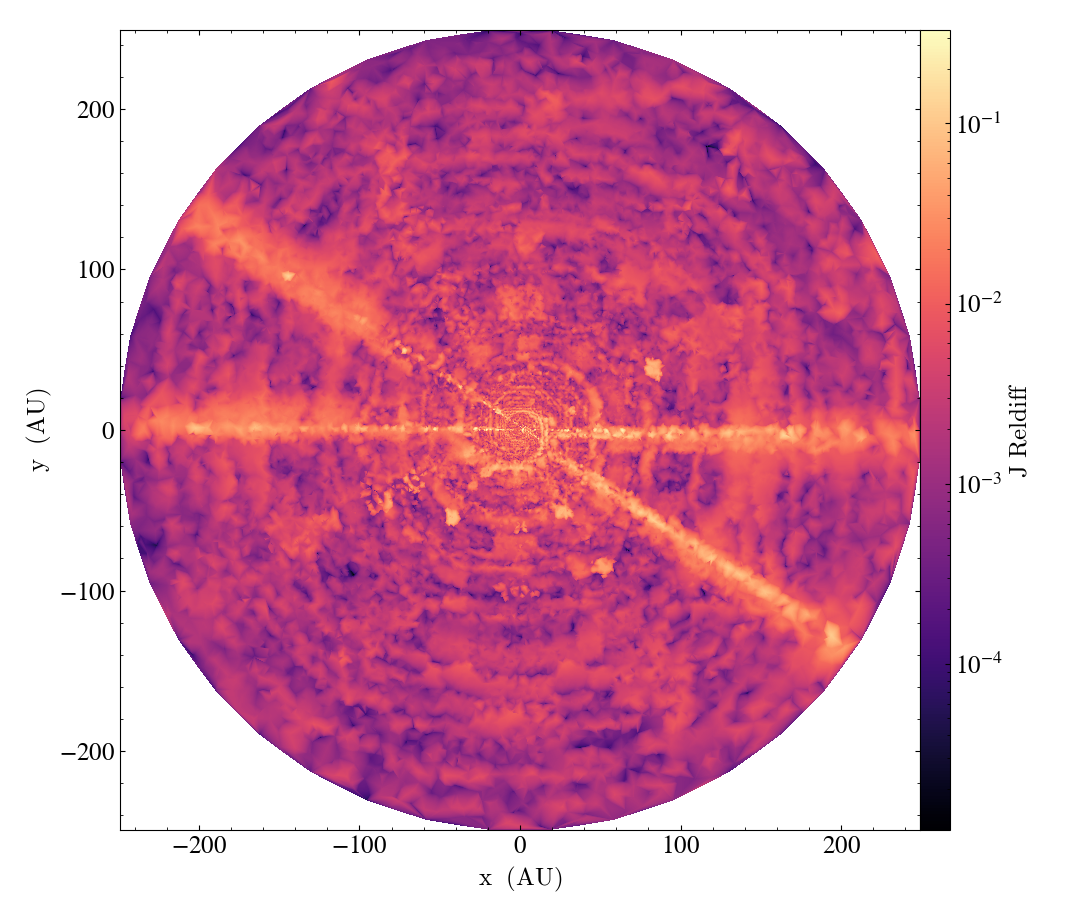

In [49]:
reldiff_original_rec = yt.load_unstructured_mesh(
    connectivity = delaunay_original.simplices.astype(np.int64),
    coordinates  = delaunay_original.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'J_reldiff'): reldiff_rec_original_grid[delaunay_original.simplices].astype(np.float64)}
)
sl = yt.SlicePlot (reldiff_original_rec, 'z', ('connect1','J_reldiff'))
sl.set_cmap       (('connect1', 'J_reldiff'), 'magma')
# sl.set_zlim(('connect1', 'J_reldiff'), zmin=(1e-6, "1"), zmax=(4e-1, "1"))
sl.zoom           (1.1)